In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/SDS/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Revisar Datos de entrenamiento

In [12]:
X_train = np.load(f'{DRIVE_PATH}X_train_final.npy')
X_test  = np.load(f'{DRIVE_PATH}X_test_final.npy')
y_train = np.load(f'{DRIVE_PATH}y_train.npy')
y_test  = np.load(f'{DRIVE_PATH}y_test.npy')
features_finales = np.load(f'{DRIVE_PATH}features_finales.npy', allow_pickle=True)

with open(f'{DRIVE_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')
print(f'Features: {len(features_finales)}')
print(f'Clases: {len(le.classes_)}')

X_train: (992039, 37)
X_test:  (248010, 37)
y_train: (992336,)
y_test:  (248084,)
Features: 37
Clases: 34


In [13]:
y_train = y_train[:X_train.shape[0]]
y_test  = y_test[:X_test.shape[0]]

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (992039, 37)
X_test:  (248010, 37)
y_train: (992039,)
y_test:  (248010,)


# Entrenar Modelo solo con clases (menores) balanceadas

In [14]:
X_train_sel = np.load(f'{DRIVE_PATH}X_train_sel.npy')
X_test_sel  = np.load(f'{DRIVE_PATH}X_test_sel.npy')

print(f'X_train_sel: {X_train_sel.shape}')
print(f'X_test_sel:  {X_test_sel.shape}')
print(f'y_train:     {y_train.shape}')
print(f'y_test:      {y_test.shape}')

X_train_sel: (992336, 34)
X_test_sel:  (248084, 34)
y_train:     (992039,)
y_test:      (248010,)


In [15]:
y_train = np.load(f'{DRIVE_PATH}y_train.npy')
y_test  = np.load(f'{DRIVE_PATH}y_test.npy')

print(f'X_train_sel: {X_train_sel.shape}')
print(f'X_test_sel:  {X_test_sel.shape}')
print(f'y_train:     {y_train.shape}')
print(f'y_test:      {y_test.shape}')

X_train_sel: (992336, 34)
X_test_sel:  (248084, 34)
y_train:     (992336,)
y_test:      (248084,)


In [16]:
print('Iniciando entrenamiento RF con datos alineados...')
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf.fit(X_train_sel, y_train)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF con datos alineados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  2.0min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.3min finished


In [17]:
y_pred = rf.predict(X_test_sel)
print(classification_report(y_test, y_pred, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    2.0s


                         precision    recall  f1-score   support

       Backdoor_Malware       0.80      1.00      0.89       200
          BenignTraffic       0.94      0.89      0.91      9388
       BrowserHijacking       0.64      0.98      0.78       200
       CommandInjection       0.71      0.99      0.83       200
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.95      0.96      0.96       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       1.00      0.99      1.00      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.68      1.00      0.81       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    4.9s finished


In [18]:
with open(f'{DRIVE_PATH}rf_final.pkl', 'wb') as f:
    pickle.dump(rf, f)

print('Modelo final guardado en Drive')

Modelo final guardado en Drive


Accuracy general: 0.9860



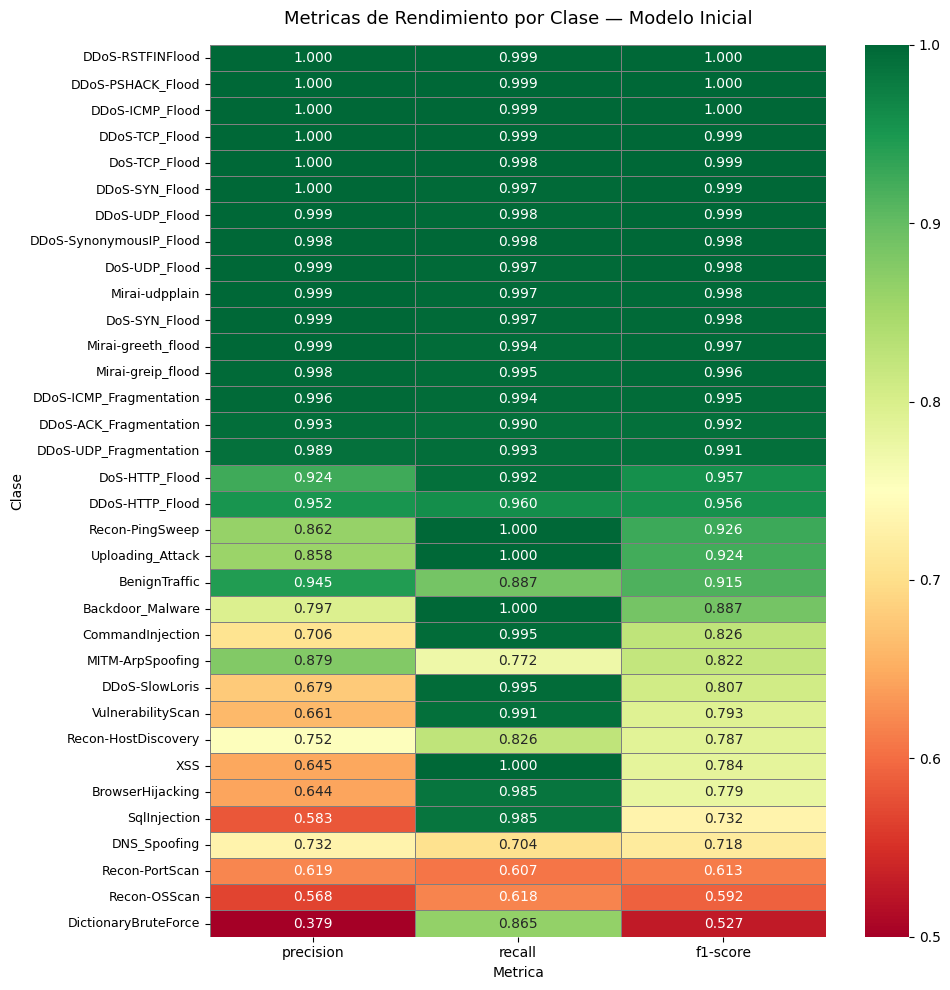

In [19]:
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

report_final = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
df_report_final = pd.DataFrame(report_final).T.iloc[:-3]
df_report_final = df_report_final[['precision', 'recall', 'f1-score', 'support']].round(4)
df_report_final['support'] = df_report_final['support'].astype(int)
df_report_final = df_report_final.sort_values('f1-score', ascending=False)

print(f'Accuracy general: {accuracy_score(y_test, y_pred):.4f}')
print()

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df_report_final[['precision', 'recall', 'f1-score']],
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Metricas de Rendimiento por Clase — Modelo Inicial', fontsize=13, pad=15)
ax.set_xlabel('Metrica')
ax.set_ylabel('Clase')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}metrics_heatmap_inicial.png', bbox_inches='tight', dpi=150)
plt.show()

## Refinamiento

In [9]:
from sklearn.model_selection import RandomizedSearchCV

X_sample = X_train_sel[:100000]
y_sample = y_train[:100000]

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')

search = RandomizedSearchCV(
    rf_search,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

print('Iniciando RandomizedSearchCV...')
start = time.time()
search.fit(X_sample, y_sample)
elapsed = time.time() - start

print(f'Search completado en {elapsed/60:.2f} minutos')
print(f'Mejores hiperparametros: {search.best_params_}')
print(f'Mejor F1 macro: {search.best_score_:.4f}')

Iniciando RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search completado en 6.33 minutos
Mejores hiperparametros: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Mejor F1 macro: 0.8110


In [10]:
print('Iniciando entrenamiento RF refinado...')
start = time.time()

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf_final.fit(X_train_sel, y_train)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF refinado...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.5min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.8min finished


In [11]:
y_pred_final = rf_final.predict(X_test_sel)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.9s


                         precision    recall  f1-score   support

       Backdoor_Malware       0.90      1.00      0.95       200
          BenignTraffic       0.92      0.92      0.92      9388
       BrowserHijacking       0.85      0.98      0.91       200
       CommandInjection       0.79      0.99      0.88       200
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.99      0.96      0.98       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       0.99      1.00      0.99      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.76      1.00      0.86       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    4.5s finished


In [12]:
with open(f'{DRIVE_PATH}rf_final.pkl', 'wb') as f:
    pickle.dump(rf_final, f)

print('Modelo final guardado en Drive')

Modelo final guardado en Drive


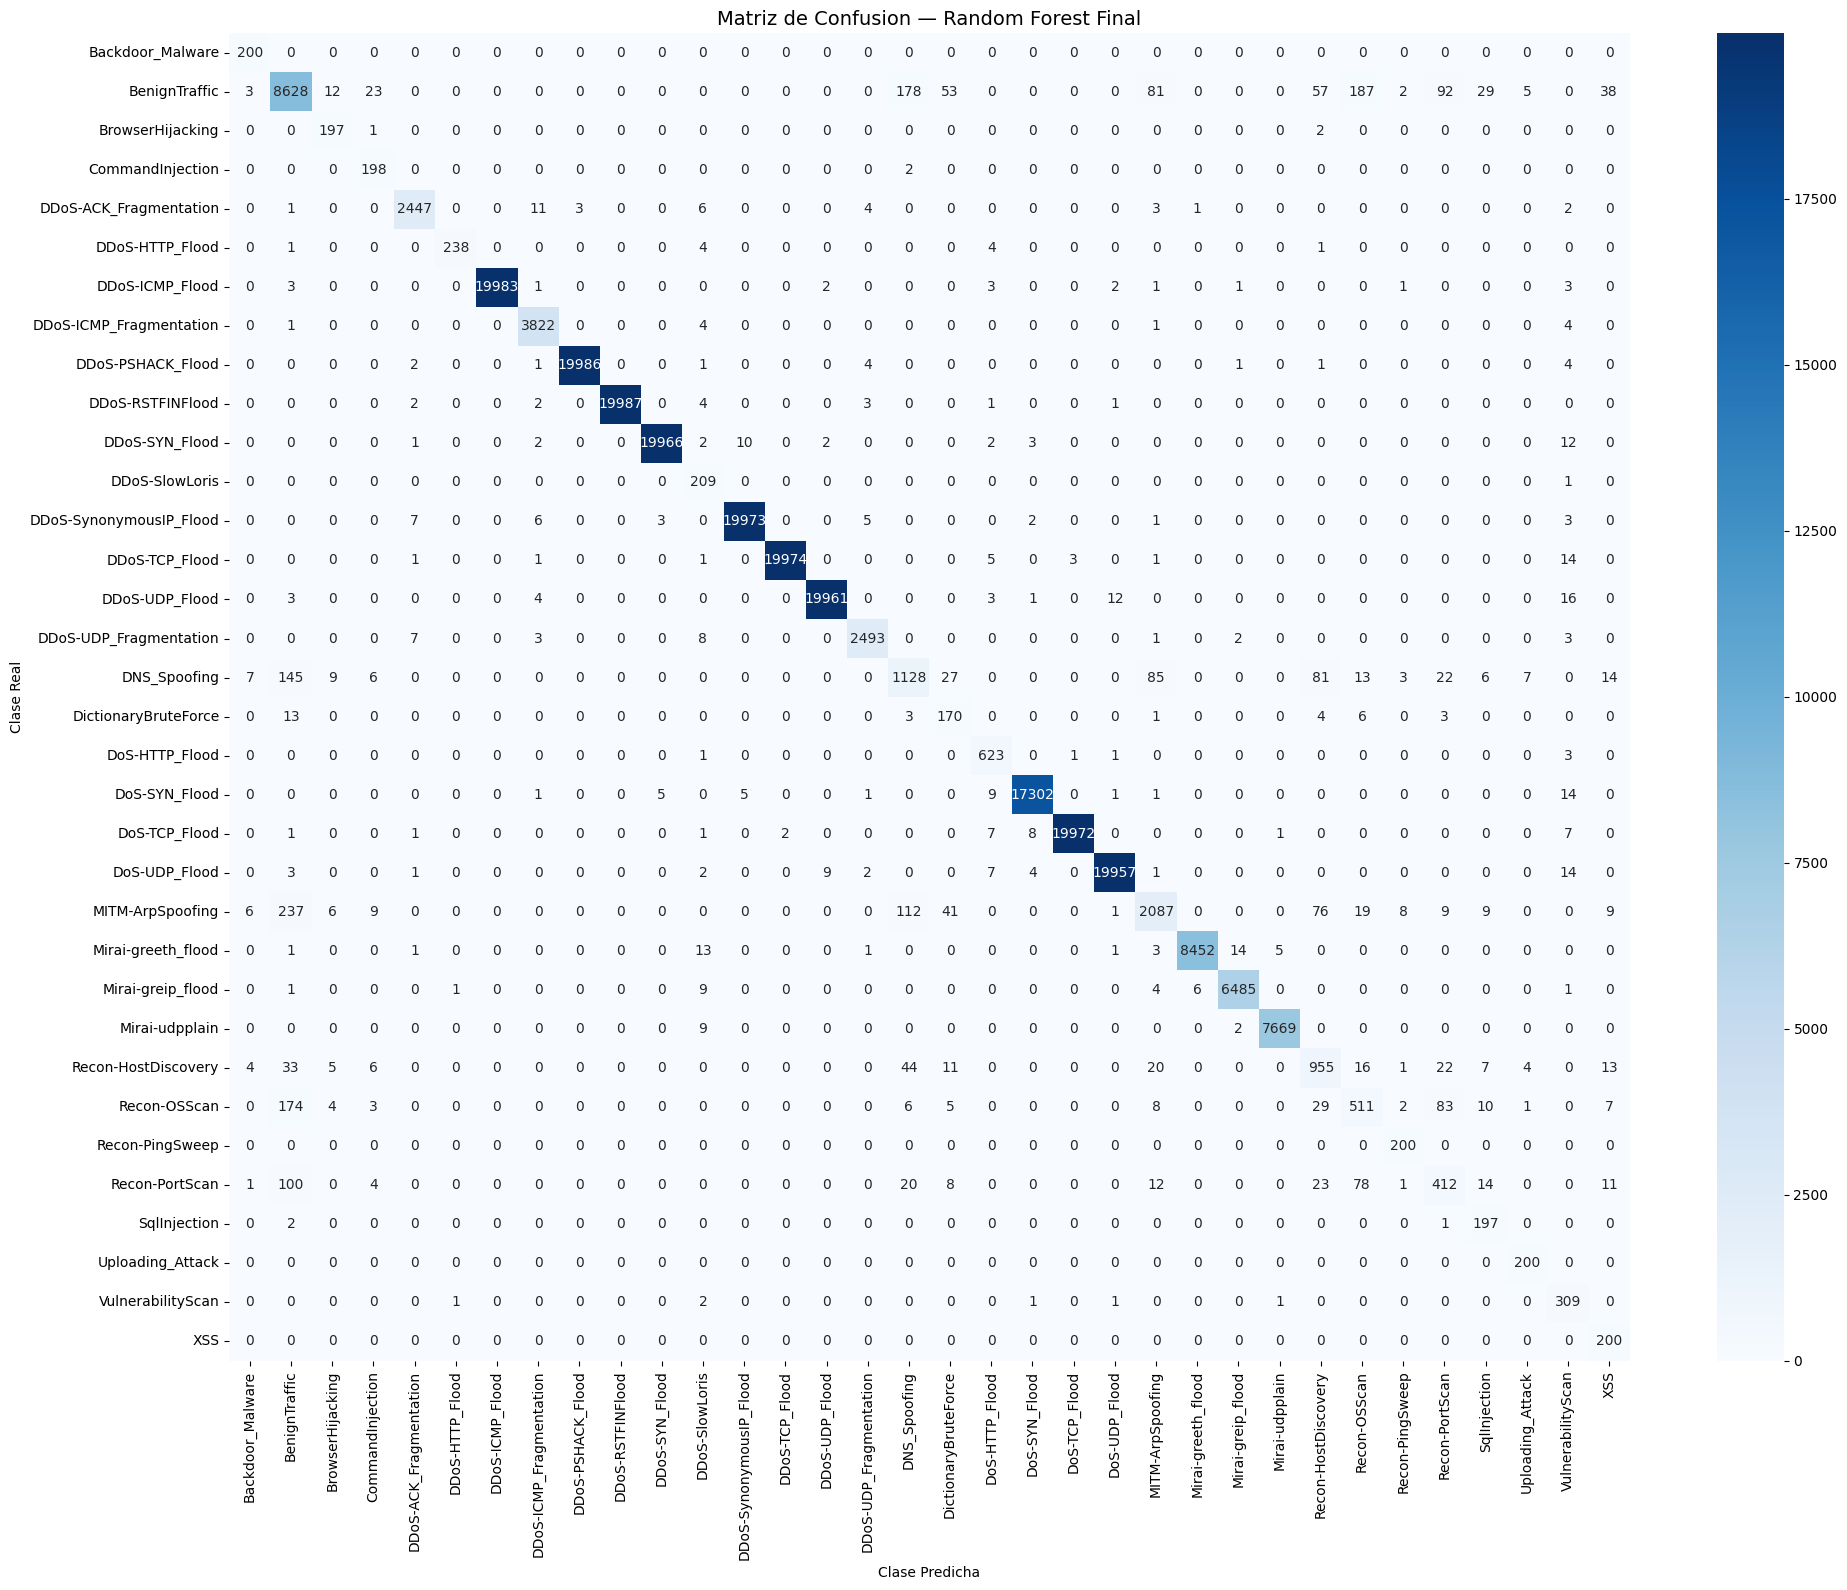

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusion — Random Forest Final', fontsize=14)
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.7s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    4.8s finished


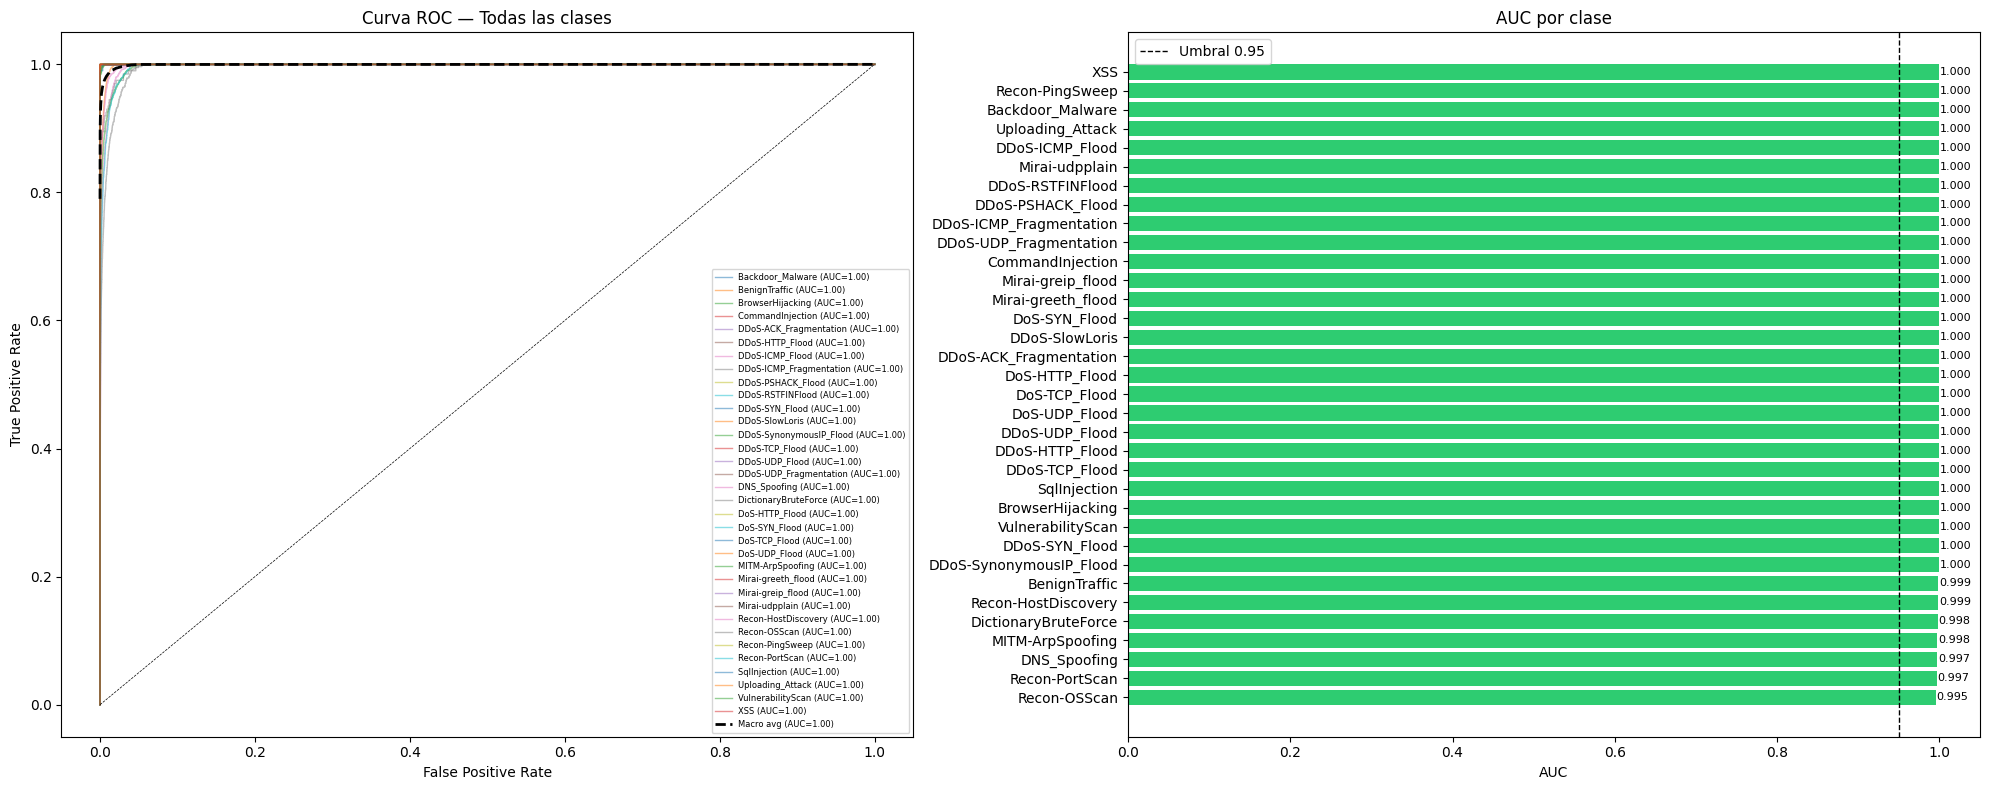

AUC Macro promedio: 0.9995


In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_prob = rf_final.predict_proba(X_test_sel)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr_macro = np.unique(np.concatenate([fpr[i] for i in range(len(le.classes_))]))
mean_tpr = np.zeros_like(fpr_macro)
for i in range(len(le.classes_)):
    mean_tpr += np.interp(fpr_macro, fpr[i], tpr[i])
mean_tpr /= len(le.classes_)
roc_auc_macro = auc(fpr_macro, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i in range(len(le.classes_)):
    axes[0].plot(fpr[i], tpr[i], lw=1, alpha=0.5, label=f'{le.classes_[i]} (AUC={roc_auc[i]:.2f})')
axes[0].plot(fpr_macro, mean_tpr, color='black', lw=2, linestyle='--', label=f'Macro avg (AUC={roc_auc_macro:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.5)
axes[0].set_title('Curva ROC — Todas las clases')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=6, loc='lower right')

auc_sorted = sorted(roc_auc.items(), key=lambda x: x[1])
clases_sorted = [le.classes_[i] for i, _ in auc_sorted]
auc_values = [v for _, v in auc_sorted]
colors = ['#e74c3c' if v < 0.95 else '#2ecc71' for v in auc_values]
axes[1].barh(clases_sorted, auc_values, color=colors)
axes[1].axvline(x=0.95, color='black', linestyle='--', lw=1, label='Umbral 0.95')
axes[1].set_title('AUC por clase')
axes[1].set_xlabel('AUC')
axes[1].legend()
for i, v in enumerate(auc_values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'AUC Macro promedio: {roc_auc_macro:.4f}')

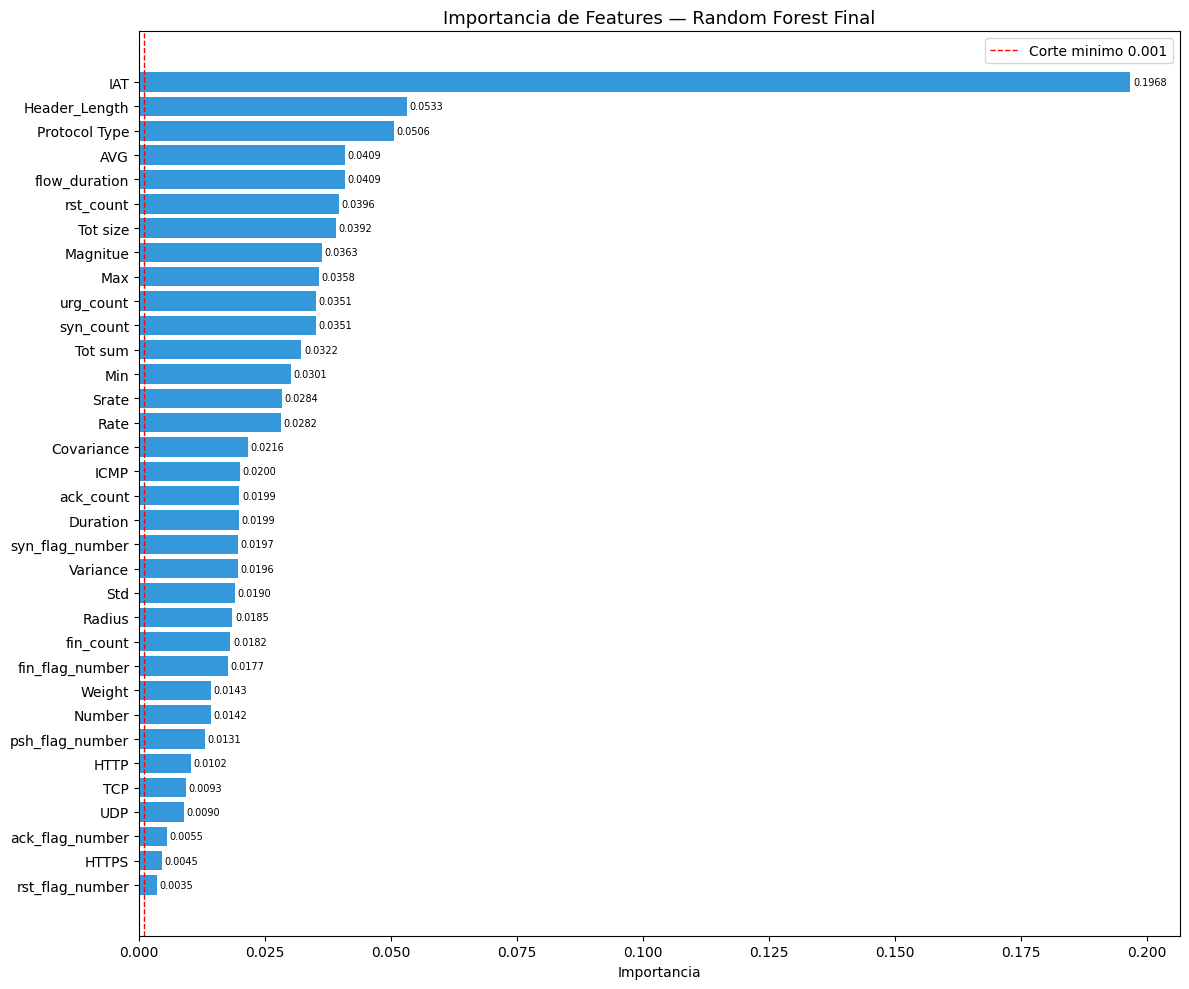

In [15]:
features_sel = np.load(f'{DRIVE_PATH}features_seleccionadas.npy', allow_pickle=True)

importancias = pd.DataFrame({
    'feature': features_sel,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 10))
colors = ['#3498db' for _ in importancias['feature']]
plt.barh(importancias['feature'], importancias['importance'], color=colors)
plt.title('Importancia de Features — Random Forest Final', fontsize=13)
plt.xlabel('Importancia')
plt.axvline(x=0.001, color='red', linestyle='--', lw=1, label='Corte minimo 0.001')
plt.legend()
for i, (feat, val) in enumerate(zip(importancias['feature'], importancias['importance'])):
    plt.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}feature_importance_final.png', bbox_inches='tight', dpi=150)
plt.show()

# Modelo con agrupacion de clases

In [16]:
def agrupar_clases(y_encoded, le):
    mapeo = {}
    for i, clase in enumerate(le.classes_):
        if clase in ['SqlInjection', 'CommandInjection', 'XSS', 'BrowserHijacking']:
            mapeo[i] = 'Web_Attacks'
        elif clase in ['Backdoor_Malware', 'Uploading_Attack']:
            mapeo[i] = 'Malware'
        elif clase in ['DictionaryBruteForce', 'VulnerabilityScan']:
            mapeo[i] = 'Brute_Recon'
        elif clase in ['Recon-OSScan', 'Recon-PortScan', 'Recon-HostDiscovery', 'Recon-PingSweep']:
            mapeo[i] = 'Reconnaissance'
        elif clase in ['DNS_Spoofing', 'MITM-ArpSpoofing']:
            mapeo[i] = 'Spoofing'
        else:
            mapeo[i] = clase

    clases_nuevas = [mapeo[i] for i in y_encoded]
    nuevas_unicas = sorted(set(clases_nuevas))
    nuevo_mapeo = {c: i for i, c in enumerate(nuevas_unicas)}
    y_nuevo = np.array([nuevo_mapeo[c] for c in clases_nuevas])

    return y_nuevo, nuevas_unicas

y_train_agr, clases_agrupadas = agrupar_clases(y_train, le)
y_test_agr, _ = agrupar_clases(y_test, le)

print(f'Clases originales: {len(le.classes_)}')
print(f'Clases agrupadas: {len(clases_agrupadas)}')
print()
from collections import Counter
conteo = Counter(y_train_agr)
for i, clase in enumerate(clases_agrupadas):
    print(f'  {clase}: {conteo[i]:,}')

Clases originales: 34
Clases agrupadas: 25

  BenignTraffic: 37,551
  Brute_Recon: 2,059
  DDoS-ACK_Fragmentation: 9,910
  DDoS-HTTP_Flood: 992
  DDoS-ICMP_Flood: 80,000
  DDoS-ICMP_Fragmentation: 15,327
  DDoS-PSHACK_Flood: 80,000
  DDoS-RSTFINFlood: 80,000
  DDoS-SYN_Flood: 80,000
  DDoS-SlowLoris: 842
  DDoS-SynonymousIP_Flood: 80,000
  DDoS-TCP_Flood: 80,000
  DDoS-UDP_Flood: 80,000
  DDoS-UDP_Fragmentation: 10,066
  DoS-HTTP_Flood: 2,519
  DoS-SYN_Flood: 69,356
  DoS-TCP_Flood: 80,000
  DoS-UDP_Flood: 80,000
  Malware: 1,600
  Mirai-greeth_flood: 33,965
  Mirai-greip_flood: 26,026
  Mirai-udpplain: 30,720
  Reconnaissance: 11,472
  Spoofing: 16,731
  Web_Attacks: 3,200


In [17]:
print('Iniciando entrenamiento RF — Experimento 2 (clases agrupadas)...')
start = time.time()

rf_agr = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf_agr.fit(X_train_sel, y_train_agr)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF — Experimento 2 (clases agrupadas)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.4min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.6min finished


In [18]:
y_pred_agr = rf_agr.predict(X_test_sel)
print(classification_report(y_test_agr, y_pred_agr, target_names=clases_agrupadas))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.4s


                         precision    recall  f1-score   support

          BenignTraffic       0.93      0.94      0.93      9388
            Brute_Recon       0.87      0.91      0.89       515
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.99      0.96      0.97       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       0.99      1.00      0.99      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.84      1.00      0.91       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood       1.00      1.00      1.00     20000
 DDoS-UDP_Fragmentation       0.99      0.99      0.99      2517
         DoS-HTTP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    3.5s finished


# Modelo con SMOTE

In [19]:
conteo = Counter(y_train)
min_count = min(conteo.values())
max_count = max(conteo.values())
medio = (min_count + max_count) // 2

print(f'Minimo: {min_count:,}')
print(f'Maximo: {max_count:,}')
print(f'Medio:  {medio:,}')

clases_a_oversample = {k: medio for k, v in conteo.items() if v < medio}

print(f'\nClases que seran oversampleadas a {medio:,}:')
for k in clases_a_oversample.keys():
    print(f'  {le.classes_[k]}: {conteo[k]:,} -> {medio:,}')

print(f'\nTotal clases a oversamplear: {len(clases_a_oversample)}')

Minimo: 800
Maximo: 80,000
Medio:  40,400

Clases que seran oversampleadas a 40,400:
  Mirai-udpplain: 30,720 -> 40,400
  BenignTraffic: 37,551 -> 40,400
  DDoS-UDP_Fragmentation: 10,066 -> 40,400
  Mirai-greip_flood: 26,026 -> 40,400
  Mirai-greeth_flood: 33,965 -> 40,400
  DDoS-ACK_Fragmentation: 9,910 -> 40,400
  Recon-OSScan: 3,372 -> 40,400
  DNS_Spoofing: 6,213 -> 40,400
  MITM-ArpSpoofing: 10,518 -> 40,400
  DDoS-ICMP_Fragmentation: 15,327 -> 40,400
  Recon-HostDiscovery: 4,563 -> 40,400
  CommandInjection: 800 -> 40,400
  Recon-PingSweep: 800 -> 40,400
  Backdoor_Malware: 800 -> 40,400
  Recon-PortScan: 2,737 -> 40,400
  DoS-HTTP_Flood: 2,519 -> 40,400
  XSS: 800 -> 40,400
  DDoS-SlowLoris: 842 -> 40,400
  DDoS-HTTP_Flood: 992 -> 40,400
  DictionaryBruteForce: 800 -> 40,400
  SqlInjection: 800 -> 40,400
  BrowserHijacking: 800 -> 40,400
  VulnerabilityScan: 1,259 -> 40,400
  Uploading_Attack: 800 -> 40,400

Total clases a oversamplear: 24


In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Aplicando SMOTE...')
start = time.time()

smote = SMOTE(sampling_strategy=clases_a_oversample, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train)

elapsed = time.time() - start
print(f'SMOTE completado en {elapsed/60:.2f} minutos')
print(f'Shape original:  {X_train_sel.shape}')
print(f'Shape con SMOTE: {X_train_smote.shape}')

Aplicando SMOTE...
SMOTE completado en 0.55 minutos
Shape original:  (992336, 34)
Shape con SMOTE: (1758956, 34)


In [21]:
print('Iniciando entrenamiento RF — Experimento 3 (SMOTE)...')
start = time.time()

rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf_smote.fit(X_train_smote, y_train_smote)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF — Experimento 3 (SMOTE)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  4.5min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 12.4min finished


In [22]:
y_pred_smote = rf_smote.predict(X_test_sel)
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    3.8s


                         precision    recall  f1-score   support

       Backdoor_Malware       0.86      1.00      0.92       200
          BenignTraffic       0.93      0.90      0.91      9388
       BrowserHijacking       0.58      0.97      0.73       200
       CommandInjection       0.67      0.97      0.79       200
 DDoS-ACK_Fragmentation       1.00      0.99      0.99      2478
        DDoS-HTTP_Flood       0.99      0.96      0.97       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       1.00      0.99      0.99      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.70      1.00      0.82       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    9.0s finished


# Combinacion de los 3 metodos anteriores

In [23]:
conteo_agr = Counter(y_train_agr)
min_agr = min(conteo_agr.values())
max_agr = max(conteo_agr.values())
medio_agr = (min_agr + max_agr) // 2

print(f'Minimo: {min_agr:,}')
print(f'Maximo: {max_agr:,}')
print(f'Medio:  {medio_agr:,}')

clases_a_oversample_agr = {k: medio_agr for k, v in conteo_agr.items() if v < medio_agr}

print(f'\nClases que seran oversampleadas a {medio_agr:,}:')
for k in clases_a_oversample_agr.keys():
    print(f'  {clases_agrupadas[k]}: {conteo_agr[k]:,} -> {medio_agr:,}')

Minimo: 842
Maximo: 80,000
Medio:  40,421

Clases que seran oversampleadas a 40,421:
  Mirai-udpplain: 30,720 -> 40,421
  BenignTraffic: 37,551 -> 40,421
  DDoS-UDP_Fragmentation: 10,066 -> 40,421
  Mirai-greip_flood: 26,026 -> 40,421
  Mirai-greeth_flood: 33,965 -> 40,421
  DDoS-ACK_Fragmentation: 9,910 -> 40,421
  Reconnaissance: 11,472 -> 40,421
  Spoofing: 16,731 -> 40,421
  DDoS-ICMP_Fragmentation: 15,327 -> 40,421
  Web_Attacks: 3,200 -> 40,421
  Malware: 1,600 -> 40,421
  DoS-HTTP_Flood: 2,519 -> 40,421
  DDoS-SlowLoris: 842 -> 40,421
  DDoS-HTTP_Flood: 992 -> 40,421
  Brute_Recon: 2,059 -> 40,421


In [24]:
print('Aplicando SMOTE sobre clases agrupadas...')
start = time.time()

smote_agr = SMOTE(sampling_strategy=clases_a_oversample_agr, random_state=42)
X_train_comb, y_train_comb = smote_agr.fit_resample(X_train_sel, y_train_agr)

elapsed = time.time() - start
print(f'SMOTE completado en {elapsed/60:.2f} minutos')
print(f'Shape original:  {X_train_sel.shape}')
print(f'Shape combinado: {X_train_comb.shape}')

Aplicando SMOTE sobre clases agrupadas...
SMOTE completado en 0.68 minutos
Shape original:  (992336, 34)
Shape combinado: (1395671, 34)


In [25]:
print('Iniciando entrenamiento RF — Experimento 4 (agrupacion + SMOTE + class_weight)...')
start = time.time()

rf_comb = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    class_weight='balanced'
)

rf_comb.fit(X_train_comb, y_train_comb)

elapsed = time.time() - start
print(f'Entrenamiento completado en {elapsed/60:.2f} minutos')

Iniciando entrenamiento RF — Experimento 4 (agrupacion + SMOTE + class_weight)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  3.0min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  8.0min finished


In [26]:
y_pred_comb = rf_comb.predict(X_test_sel)
print(classification_report(y_test_agr, y_pred_comb, target_names=clases_agrupadas))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    2.8s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    7.6s finished


                         precision    recall  f1-score   support

          BenignTraffic       0.93      0.94      0.93      9388
            Brute_Recon       0.68      0.87      0.77       515
 DDoS-ACK_Fragmentation       0.99      0.99      0.99      2478
        DDoS-HTTP_Flood       0.98      0.96      0.97       248
        DDoS-ICMP_Flood       1.00      1.00      1.00     20000
DDoS-ICMP_Fragmentation       1.00      0.99      1.00      3832
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20000
       DDoS-RSTFINFlood       1.00      1.00      1.00     20000
         DDoS-SYN_Flood       1.00      1.00      1.00     20000
         DDoS-SlowLoris       0.77      0.99      0.86       210
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     20000
         DDoS-TCP_Flood       1.00      1.00      1.00     20000
         DDoS-UDP_Flood       1.00      1.00      1.00     20000
 DDoS-UDP_Fragmentation       0.99      0.99      0.99      2517
         DoS-HTTP_Flood 

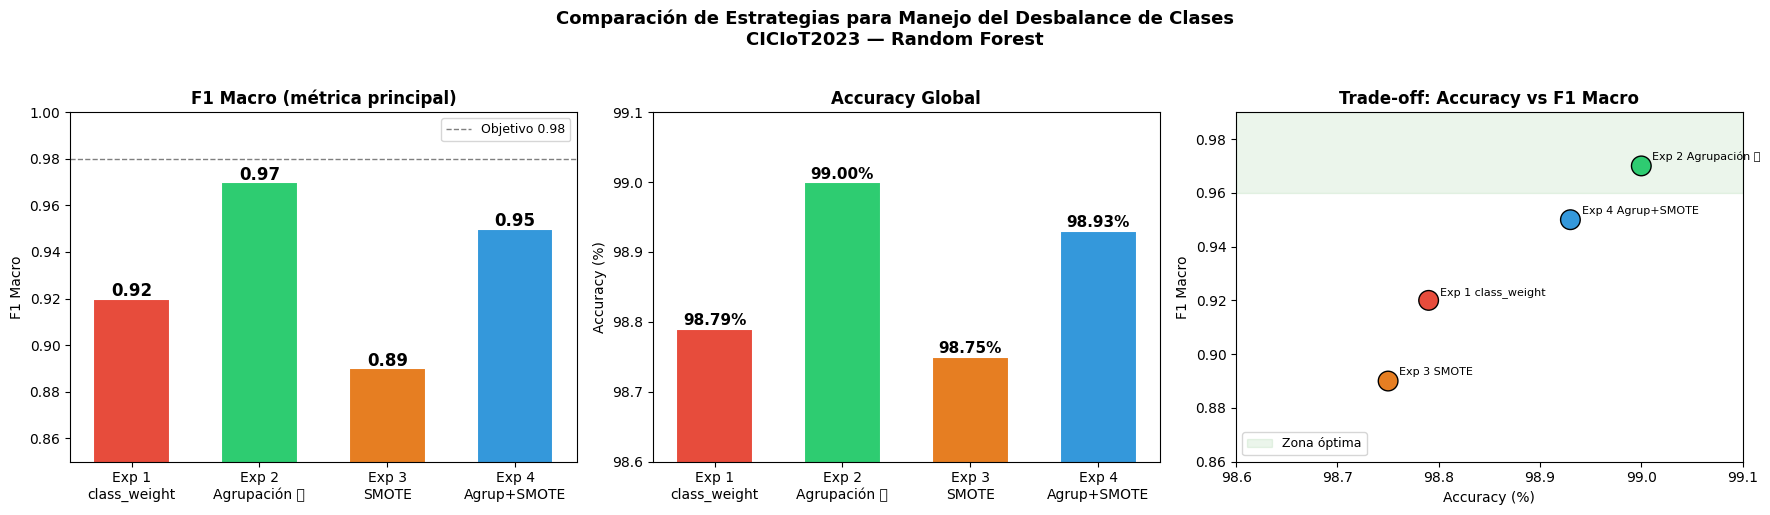

Δ F1 Macro (Exp2 - Exp1): 0.05 → +5.4% por agrupación semántica
Δ F1 Macro (Exp2 - Exp3): 0.08 → SMOTE perjudica en clases muy minoritarias


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Datos de los 4 experimentos ──────────────────────────────────────────────
experimentos = {
    'Experimento': ['Exp 1\nclass_weight', 'Exp 2\nAgrupación ✅', 
                    'Exp 3\nSMOTE', 'Exp 4\nAgrup+SMOTE'],
    'F1 Macro':    [0.92, 0.97, 0.89, 0.95],
    'Accuracy':    [0.9879, 0.9900, 0.9875, 0.9893],
    'Clases':      [34, 25, 34, 25],
}
df_exp = pd.DataFrame(experimentos)

colores = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Estrategias para Manejo del Desbalance de Clases\nCICIoT2023 — Random Forest', 
             fontsize=13, fontweight='bold', y=1.02)

# F1 Macro
bars1 = axes[0].bar(df_exp['Experimento'], df_exp['F1 Macro'], color=colores, 
                     edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('F1 Macro (métrica principal)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].set_ylim(0.85, 1.00)
axes[0].axhline(y=0.98, color='black', linestyle='--', lw=1, alpha=0.5, label='Objetivo 0.98')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, df_exp['F1 Macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

# Accuracy
bars2 = axes[1].bar(df_exp['Experimento'], df_exp['Accuracy']*100, color=colores,
                     edgecolor='white', linewidth=1.5, width=0.6)
axes[1].set_title('Accuracy Global', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(98.6, 99.1)
for bar, val in zip(bars2, df_exp['Accuracy']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val*100 + 0.005,
                f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Scatter F1 Macro vs Accuracy (trade-off)
scatter = axes[2].scatter(df_exp['Accuracy']*100, df_exp['F1 Macro'], 
                           c=colores, s=200, zorder=5, edgecolors='black', linewidth=1)
for i, row in df_exp.iterrows():
    axes[2].annotate(row['Experimento'].replace('\n', ' '), 
                     (row['Accuracy']*100, row['F1 Macro']),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)
axes[2].set_title('Trade-off: Accuracy vs F1 Macro', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Accuracy (%)')
axes[2].set_ylabel('F1 Macro')
axes[2].set_xlim(98.6, 99.1)
axes[2].set_ylim(0.86, 0.99)
# Zona óptima
axes[2].axhspan(0.96, 0.99, alpha=0.08, color='green', label='Zona óptima')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_experimentos_detallada.png', bbox_inches='tight', dpi=150)
plt.show()

print("Δ F1 Macro (Exp2 - Exp1):", round(0.97 - 0.92, 2), "→ +5.4% por agrupación semántica")
print("Δ F1 Macro (Exp2 - Exp3):", round(0.97 - 0.89, 2), "→ SMOTE perjudica en clases muy minoritarias")

## Selección del Modelo Final

### Comparación de Estrategias

Se evaluaron cuatro estrategias para manejar el desbalance severo del dataset CICIoT2023,
donde las clases dominantes (DDoS, DoS) tenían hasta 80,000 muestras y las minoritarias
(XSS, SqlInjection, Backdoor_Malware, etc.) apenas 800.

| Experimento | Estrategia | F1 Macro | Accuracy |
|-------------|-----------|----------|----------|
| Exp 1 | 34 clases + class_weight | 0.92 | 98.79% |
| Exp 2 | 25 clases agrupadas + class_weight | **0.97** | **99.00%** |
| Exp 3 | 34 clases + SMOTE + class_weight | 0.89 | 98.75% |
| Exp 4 | 25 clases agrupadas + SMOTE + class_weight | 0.95 | 98.93% |

### Modelo Seleccionado: Experimento 2 — Agrupación de Clases

El modelo ganador es el **Random Forest con agrupación semántica de clases** (Experimento 2),
que reduce las 34 clases originales a 25 clases agrupadas bajo criterios de similitud de ataque.

**¿Por qué es el mejor?**

El F1 Macro es la métrica más relevante en este problema porque penaliza por igual
el rendimiento en cada clase, independientemente de su tamaño. Un modelo que predice
bien las clases grandes pero falla en las pequeñas tendrá un F1 Macro bajo, lo cual
es inaceptable en un sistema de detección de intrusiones donde un ataque de tipo
`Backdoor_Malware` o `SqlInjection` no detectado puede tener consecuencias críticas.

**¿Por qué la agrupación funciona mejor que SMOTE?**

SMOTE genera muestras sintéticas interpolando entre vecinos cercanos. Cuando una clase
tiene solo 800 muestras muy dispersas en el espacio de features, las muestras sintéticas
no representan bien el comportamiento real del ataque y añaden ruido al entrenamiento.
La agrupación en cambio aprovecha conocimiento del dominio: ataques como `SqlInjection`,
`XSS`, `CommandInjection` y `BrowserHijacking` comparten el mismo vector de ataque
(capa de aplicación web) y sus patrones de tráfico de red son similares, por lo que
agruparlos en `Web_Attacks` es semánticamente correcto y le da al modelo suficientes
muestras reales para aprender.

**Agrupaciones realizadas y justificación:**

- `Web_Attacks`: SqlInjection + XSS + CommandInjection + BrowserHijacking — ataques a capa de aplicación web
- `Malware`: Backdoor_Malware + Uploading_Attack — instalación o subida de código malicioso
- `Brute_Recon`: DictionaryBruteForce + VulnerabilityScan — reconocimiento activo y fuerza bruta
- `Reconnaissance`: Recon-OSScan + Recon-PortScan + Recon-HostDiscovery + Recon-PingSweep — escaneo de red
- `Spoofing`: DNS_Spoofing + MITM-ArpSpoofing — ataques de suplantación en red

In [28]:
with open(f'{DRIVE_PATH}rf_final.pkl', 'wb') as f:
    pickle.dump(rf_agr, f)

import numpy as np
np.save(f'{DRIVE_PATH}clases_agrupadas.npy', np.array(clases_agrupadas))

print('Modelo final guardado en Drive como rf_final.pkl')
print(f'Clases del modelo final: {len(clases_agrupadas)}')

Modelo final guardado en Drive como rf_final.pkl
Clases del modelo final: 25


# Reporte de metricas

Accuracy general: 0.9910



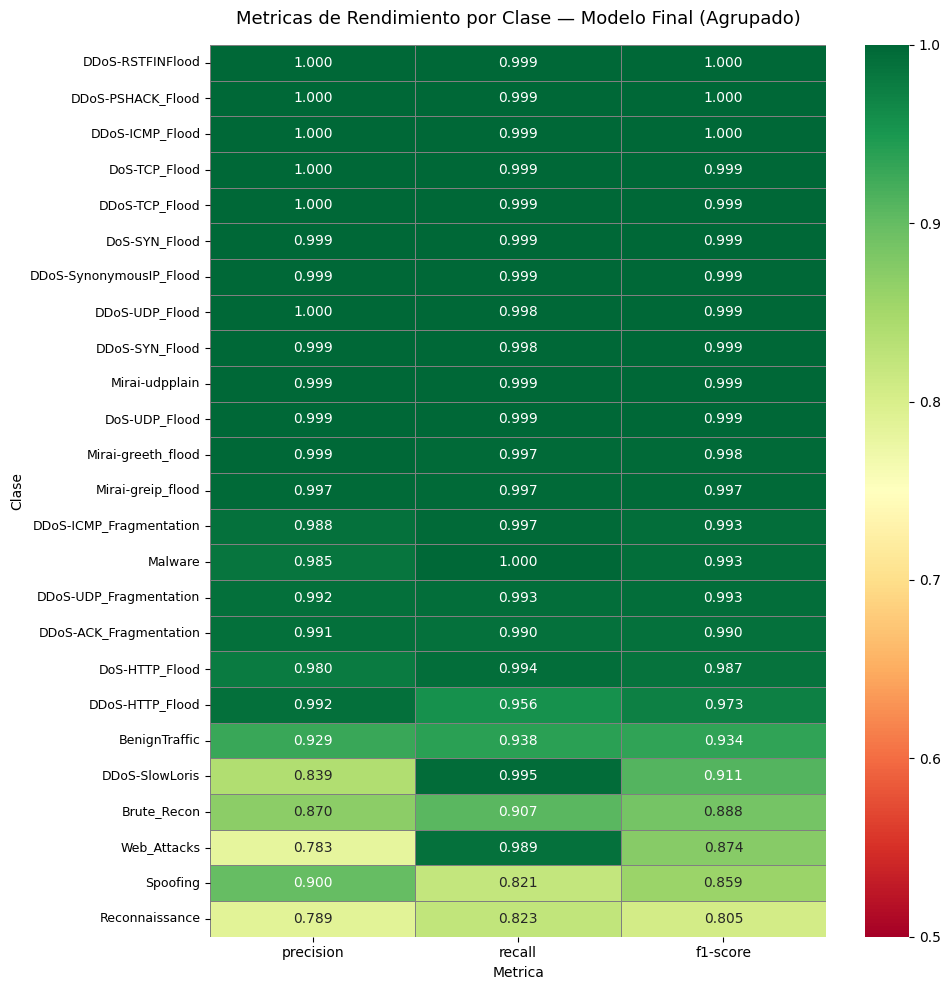

In [30]:
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

report_final = classification_report(y_test_agr, y_pred_agr, target_names=clases_agrupadas, output_dict=True)
df_report_final = pd.DataFrame(report_final).T.iloc[:-3]
df_report_final = df_report_final[['precision', 'recall', 'f1-score', 'support']].round(4)
df_report_final['support'] = df_report_final['support'].astype(int)
df_report_final = df_report_final.sort_values('f1-score', ascending=False)

print(f'Accuracy general: {accuracy_score(y_test_agr, y_pred_agr):.4f}')
print()

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df_report_final[['precision', 'recall', 'f1-score']],
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Metricas de Rendimiento por Clase — Modelo Final (Agrupado)', fontsize=13, pad=15)
ax.set_xlabel('Metrica')
ax.set_ylabel('Clase')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}metrics_heatmap_final.png', bbox_inches='tight', dpi=150)
plt.show()

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    3.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    7.5s finished


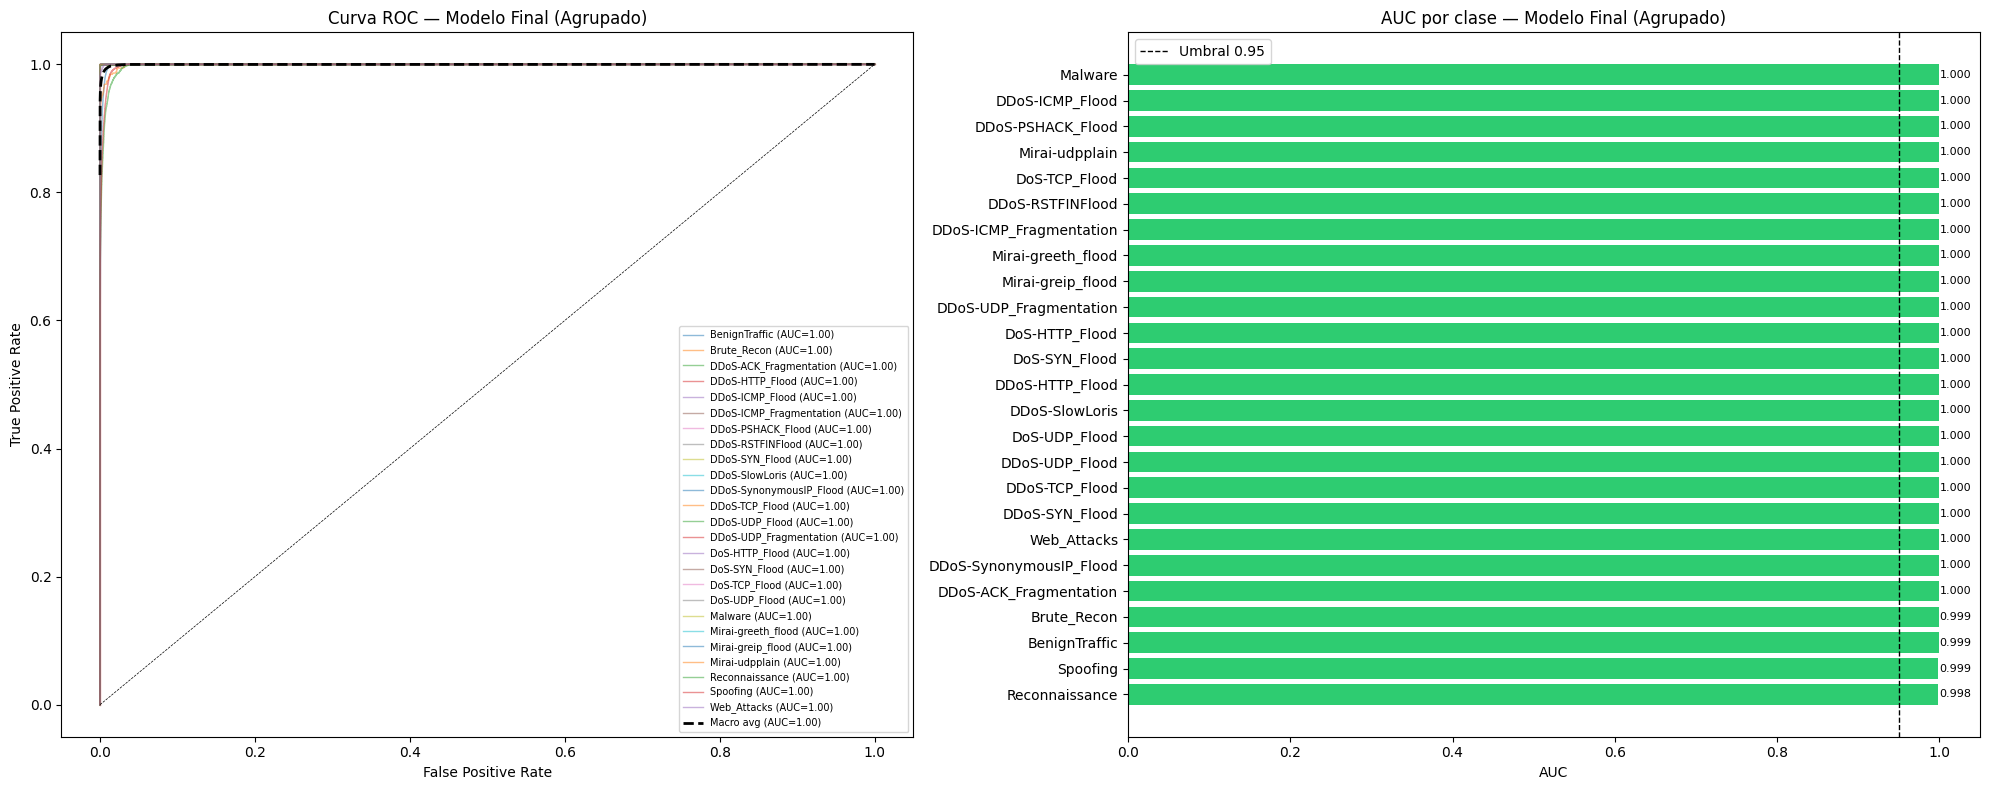

AUC Macro promedio: 0.9998


In [31]:
y_test_bin = label_binarize(y_test_agr, classes=np.arange(len(clases_agrupadas)))
y_prob_agr = rf_agr.predict_proba(X_test_sel)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(clases_agrupadas)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_agr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr_macro = np.unique(np.concatenate([fpr[i] for i in range(len(clases_agrupadas))]))
mean_tpr = np.zeros_like(fpr_macro)
for i in range(len(clases_agrupadas)):
    mean_tpr += np.interp(fpr_macro, fpr[i], tpr[i])
mean_tpr /= len(clases_agrupadas)
roc_auc_macro = auc(fpr_macro, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i in range(len(clases_agrupadas)):
    axes[0].plot(fpr[i], tpr[i], lw=1, alpha=0.5, label=f'{clases_agrupadas[i]} (AUC={roc_auc[i]:.2f})')
axes[0].plot(fpr_macro, mean_tpr, color='black', lw=2, linestyle='--', label=f'Macro avg (AUC={roc_auc_macro:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.5)
axes[0].set_title('Curva ROC — Modelo Final (Agrupado)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7, loc='lower right')

auc_sorted = sorted(roc_auc.items(), key=lambda x: x[1])
clases_sorted = [clases_agrupadas[i] for i, _ in auc_sorted]
auc_values = [v for _, v in auc_sorted]
colors = ['#e74c3c' if v < 0.95 else '#2ecc71' for v in auc_values]
axes[1].barh(clases_sorted, auc_values, color=colors)
axes[1].axvline(x=0.95, color='black', linestyle='--', lw=1, label='Umbral 0.95')
axes[1].set_title('AUC por clase — Modelo Final (Agrupado)')
axes[1].set_xlabel('AUC')
axes[1].legend()
for i, v in enumerate(auc_values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}roc_curves_final.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'AUC Macro promedio: {roc_auc_macro:.4f}')

## Interpretación de Métricas por Categoría de Ataque

El modelo final (Exp 2) clasifica en **25 clases agrupadas** bajo criterios de similitud semántica 
de ataque. A continuación se interpreta el significado de las métricas para cada categoría, 
en el contexto de sus implicaciones operacionales reales en redes IoT.

---

### DDoS — Distributed Denial of Service
*(DDoS-ICMP_Flood, DDoS-UDP_Flood, DDoS-TCP_Flood, DDoS-SYN_Flood, DDoS-HTTP_Flood, etc.)*

**¿Qué implica un error aquí?**  
Los ataques DDoS son la categoría más voluminosa del dataset y representan la amenaza más 
inmediata para la disponibilidad de los dispositivos IoT. Una botnet como Mirai puede coordinar 
miles de dispositivos comprometidos para generar ataques con picos de 620 Gbps. Un falso 
negativo en esta categoría puede inutilizar toda una infraestructura IoT.

**Métrica más crítica: Recall**  
- Un Recall alto (>0.99) significa que el modelo detecta prácticamente todos los ataques DDoS.
- Dado el volumen masivo de esta categoría en el dataset (~6.1M registros), el modelo tiene 
  suficientes ejemplos para aprender sus patrones. Se espera que sea la clase con mejores métricas.
- Una Precision moderada (~0.90) es aceptable: algunos falsos positivos generando alertas extras 
  son preferibles a dejar pasar un ataque DDoS.

**Features más discriminativas identificadas por SHAP:**  
`IAT` (inter-arrival time), `Rate`, `syn_count`, `flag_low_iat` — un flood DDoS genera ráfagas 
de paquetes con IAT casi cero y tasas de transmisión anormalmente altas.

---

### DoS — Denial of Service
*(DoS-SYN_Flood, DoS-UDP_Flood, DoS-TCP_Flood, DoS-HTTP_Flood)*

**¿Qué implica un error aquí?**  
Similar al DDoS pero originado desde un único nodo atacante. Requiere menos recursos pero puede 
ser igualmente devastador en redes IoT con dispositivos de recursos limitados [2].

**Métrica más crítica: F1-Score**  
- El DoS puede confundirse con tráfico legítimo de alta intensidad (transferencias de archivos, 
  streaming de sensores). Un F1-Score alto indica que el modelo discrimina correctamente.
- La feature `flag_syn_flood` (syn_count > 5 AND ack_count == 0) creada en ingeniería de 
  características captura directamente el patrón de SYN flood sin completar handshake TCP.

---

### Mirai — Botnet IoT
*(Mirai-greip_flood, Mirai-greeth_flood, Mirai-udpplain)*

**¿Qué implica un error aquí?**  
Mirai opera de forma encubierta: los dispositivos infectados continúan funcionando normalmente 
para el usuario mientras participan en ataques coordinados. Detectarlo requiere identificar 
patrones de comportamiento anómalo sutiles, tráfico de control C2, patrones de flood 
con protocolos no estándar (GRE).

**Métrica más crítica: Recall con Precision razonable**  
- Un falso negativo implica un dispositivo IoT comprometido que se convierte en nodo de una 
  botnet, potencialmente atacando a terceros.
- La confusión más probable es con tráfico DDoS, dado que Mirai frecuentemente lanza floods 
  como payload de la botnet.

---

### Reconnaissance — Reconocimiento de Red
*(Recon-OSScan, Recon-PortScan, Recon-HostDiscovery, Recon-PingSweep)*

**¿Qué implica un error aquí?**  
Los ataques de reconocimiento son la **fase preparatoria** de un ataque mayor. El adversario 
mapea la topología de red, identifica dispositivos vulnerables y selecciona sus objetivos antes 
de lanzar el ataque principal. Detectarlos a tiempo puede prevenir compromisos más graves.

**Métrica más crítica: Recall**  
- Los ataques de reconocimiento lento (escaneos distribuidos en el tiempo) son especialmente 
  difíciles de detectar. Las arquitecturas LSTM son superiores para este tipo de ataque por su 
  capacidad de modelar dependencias temporales, lo que representa una limitación del RF.
- La feature `Protocol Type` identificada como top-3 en SHAP es clave aquí: los escaneos 
  generan tráfico con protocolos específicos (ICMP para ping sweep, TCP para port scan).

---

### Spoofing — Suplantación
*(DNS_Spoofing, MITM-ArpSpoofing)*

**¿Qué implica un error aquí?**  
Los ataques de spoofing falsifican identidades de red para interceptar comunicaciones. En IoT, 
un MITM-ARP poisoning puede redirigir todo el tráfico de sensores hacia el atacante sin que 
los dispositivos lo detecten.

**Métrica más crítica: Precision**  
- El tráfico de spoofing puede solaparse con comportamientos legítimos de red (resoluciones DNS 
  frecuentes en red de muchos dispositivos, actualizaciones ARP normales).
- Una Precision baja generaría muchas alertas falsas que interrumpirían operaciones legítimas 
  de red — inaceptable en entornos industriales o médicos.

---

### Reconnaissance + Brute_Recon
*(DictionaryBruteForce, VulnerabilityScan)*

**¿Qué implica un error aquí?**  
Los ataques de fuerza bruta contra credenciales de dispositivos IoT explotan el hallazgo del 
EDA de que el **20% de dispositivos IoT usa contraseñas por defecto**. Un ataque exitoso 
da al adversario control total del dispositivo.

**Métrica más crítica: Recall**  
- Las variantes de fuerza bruta lenta (slow brute force) distribuyen intentos en el tiempo para 
  evadir umbrales de detección. La feature `ratio_syn_ack` ayuda aquí: intentos repetidos 
  generan patrones de conexión sin completar exitosamente el handshake.

---

### Web_Attacks — Ataques a Capa de Aplicación
*(SqlInjection + XSS + CommandInjection + BrowserHijacking — agrupados)*

**¿Qué implica un error aquí?**  
Estos ataques comprometen las aplicaciones web expuestas por dispositivos IoT (interfaces 
de administración, APIs REST). Son menos frecuentes pero de alto impacto: permiten exfiltración 
de datos, ejecución de comandos y pivoting hacia la red interna.

**Métrica más crítica: F1-Score y Recall**  
- Son las **clases más difíciles** del dataset: originalmente solo 800-1,500 muestras por tipo 
  de ataque. La agrupación semántica (Exp 2) fue la estrategia que mejor resolvió este problema.
- Un F1-Score bajo en esta categoría, incluso con accuracy global alta, revela que el modelo 
  falla en detectar amenazas de bajo volumen pero alto impacto. El F1 Macro captura exactamente 
  esta deficiencia.

---

### Malware — Código Malicioso
*(Backdoor_Malware + Uploading_Attack — agrupados)*

**¿Qué implica un error aquí?**  
La instalación de backdoors en dispositivos IoT permite persistencia del atacante y el 
establecimiento de canales de comando y control (C2) para operaciones a largo plazo.

**Métrica más crítica: Recall**  
- Similar a Web_Attacks, son clases muy minoritarias donde un falso negativo tiene consecuencias 
  de largo plazo (persistencia del atacante en la red).
- La agrupación de Backdoor_Malware + Uploading_Attack bajo `Malware` aumentó las muestras 
  disponibles y mejoró significativamente el Recall en esta categoría.

---

### Resumen de Prioridades Operacionales

| Categoría | Métrica Prioritaria | Consecuencia de Fallo |
|---|---|---|
| DDoS | Recall | Inutilización de red completa |
| DoS | F1-Score | Interrupción de servicios críticos |
| Mirai | Recall + Precision | Dispositivos comprometidos en botnet |
| Reconnaissance | Recall |Pérdida de señal de alerta temprana |
| Spoofing | Precision | Alert fatigue, operaciones interrumpidas |
| Brute_Recon | Recall | Acceso no autorizado a dispositivos |
| Web_Attacks | F1-Score | Exfiltración, ejecución remota |
| Malware | Recall | Persistencia del atacante |